# Fase 1 — Reconocimiento de Patrones: Firmas Off-Line (Dataset Personal)

## Universidad Autónoma de Aguascalientes
## Ingeniería en Computación Inteligente — Machine y Deep Learning
## Maestro: Dr. Francisco Javier Luna Rosas
## Alumno: Guillermo González Lara (237864) — Semestre Enero–Junio 2026

---

**Descripción general**

A diferencia del proyecto anterior (que disponía de máscaras pre-generadas para entrenar una U-Net), este notebook trabaja directamente con fotografías de firmas reales y falsificadas realizadas por el propio alumno. Al no contar con ground truth de segmentación, la extracción de firma se realiza mediante **procesamiento clásico de imagen**.

```
dataset/
├── real/          ← 15 imágenes con firma auténtica
├── fake/          ← 15 imágenes con firma falsificada
├── real_test.jpg  ← imagen de prueba final (auténtica)
└── fake_test.jpg  ← imagen de prueba final (falsificada)
```

**Flujo completo:**
```
Imagen con firma
      │
      ▼
 Preprocesamiento clásico
 (gris → umbral adaptativo → morfología → bounding box)
      │
      ▼
 Firma binarizada normalizada (128×256 px)
      │
      ▼
 54 EE morfológicos → vector de 54 características
      │
      ▼
 BPNN · SVM · KNN · Naive Bayes
      │
      ▼
 Auténtica / Falsificación
```
---

## 0 · Dependencias

In [102]:
# !pip install opencv-python-headless numpy matplotlib scikit-image scikit-learn scipy tqdm -q

import os, glob, warnings, random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm
from scipy.ndimage import rotate as ndrotate
from skimage.morphology import binary_erosion

from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc
)
from sklearn.model_selection import cross_val_score, StratifiedKFold

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

print('✔  Dependencias cargadas correctamente.')

✔  Dependencias cargadas correctamente.


---
## Etapa 1 · Selección de Datos
### Adquisición de imágenes con firmas off-line

El conjunto de datos consiste en 15 fotografías de la firma auténtica del alumno y 15 fotografías de una firma falsificada, organizadas en las carpetas `/real` y `/fake`.

In [103]:
# ── Configuración de rutas ────────────────────────────────────────────────────
DATASET_ROOT = './content/sample_data/dataset'

REAL_DIR  = os.path.join(DATASET_ROOT, 'real')
FAKE_DIR  = os.path.join(DATASET_ROOT, 'fake')
TEST_REAL = os.path.join(DATASET_ROOT, 'real_test.jpg')
TEST_FAKE = os.path.join(DATASET_ROOT, 'fake_test.jpg')

IMG_EXTS = ('*.png', '*.jpg', '*.jpeg', '*.bmp', '*.tif', '*.tiff')

def load_paths(folder):
    paths = []
    for ext in IMG_EXTS:
        paths.extend(glob.glob(os.path.join(folder, ext)))
    return sorted(paths)

real_paths = load_paths(REAL_DIR)
fake_paths = load_paths(FAKE_DIR)

assert len(real_paths) > 0, f'No se encontraron imágenes en {REAL_DIR}'
assert len(fake_paths) > 0, f'No se encontraron imágenes en {FAKE_DIR}'
assert os.path.exists(TEST_REAL), f'No se encontró {TEST_REAL}'
assert os.path.exists(TEST_FAKE), f'No se encontró {TEST_FAKE}'

print(f'Firmas auténticas : {len(real_paths)}')
print(f'Firmas falsificadas: {len(fake_paths)}')
print(f'Imagen de prueba real : {TEST_REAL}')
print(f'Imagen de prueba fake : {TEST_FAKE}')

Firmas auténticas : 15
Firmas falsificadas: 15
Imagen de prueba real : ./content/sample_data/dataset\real_test.jpg
Imagen de prueba fake : ./content/sample_data/dataset\fake_test.jpg


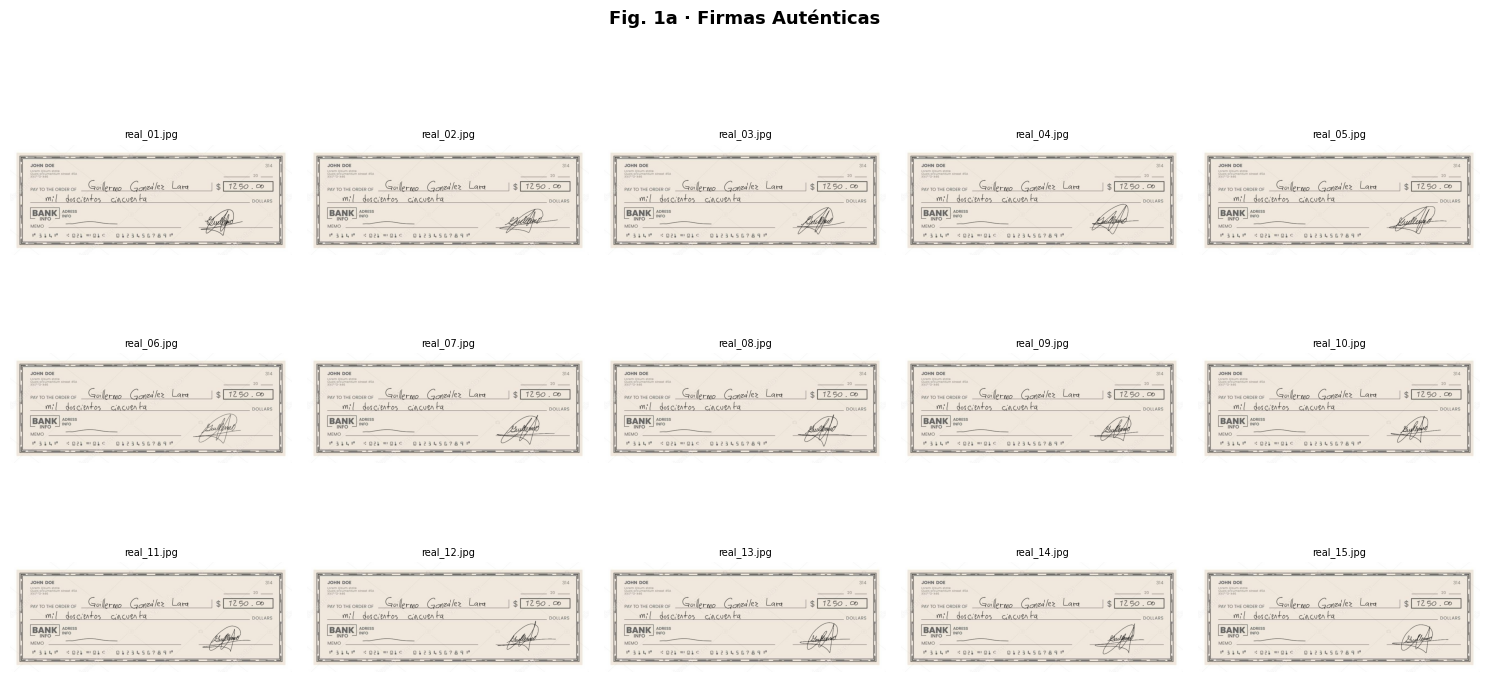

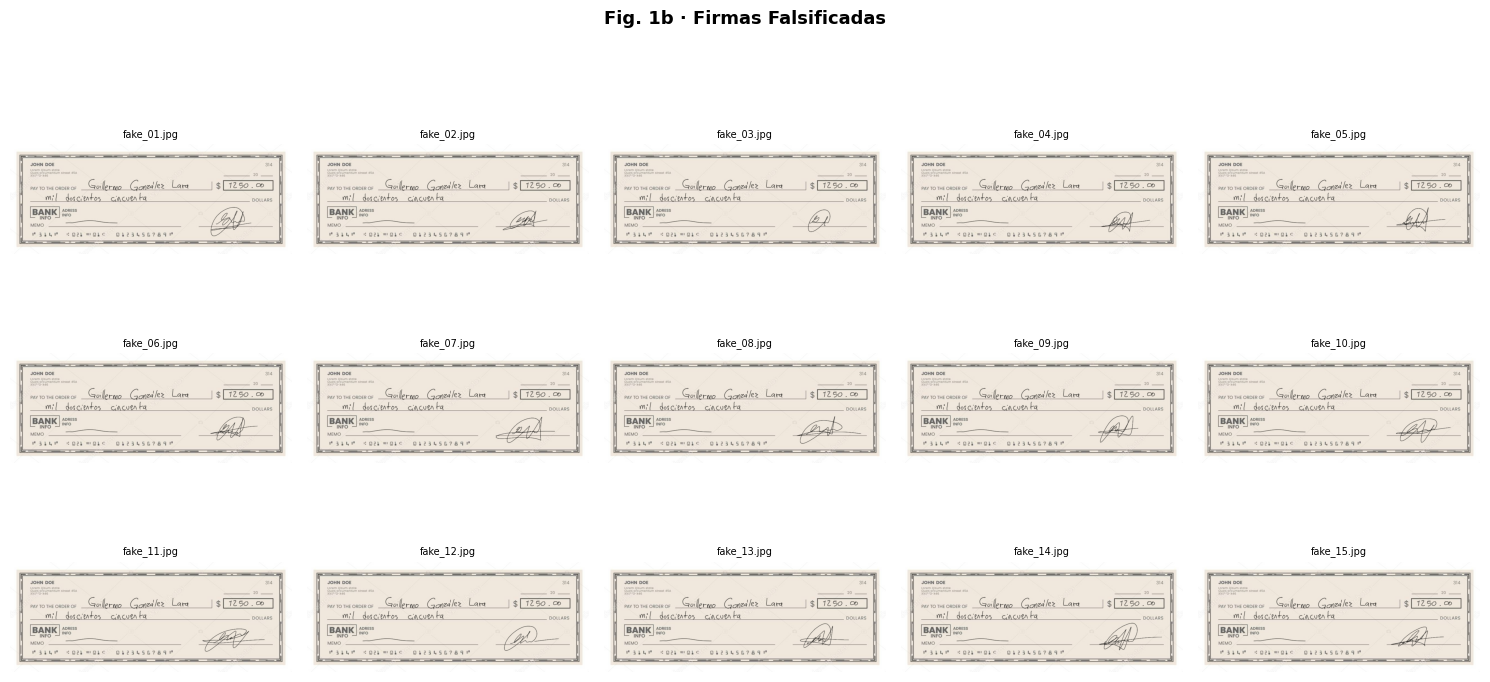

In [104]:
# ── Fig. 1 · Mosaico de la base de datos ─────────────────────────────────────
def plot_mosaic(paths, title, cols=5):
    rows = (len(paths) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*2.5))
    axes = np.array(axes).flatten()
    for ax, p in zip(axes, paths):
        img = cv2.imread(p)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(os.path.basename(p), fontsize=7)
        ax.axis('off')
    for ax in axes[len(paths):]: ax.axis('off')
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

plot_mosaic(real_paths, 'Fig. 1a · Firmas Auténticas')
plot_mosaic(fake_paths, 'Fig. 1b · Firmas Falsificadas')

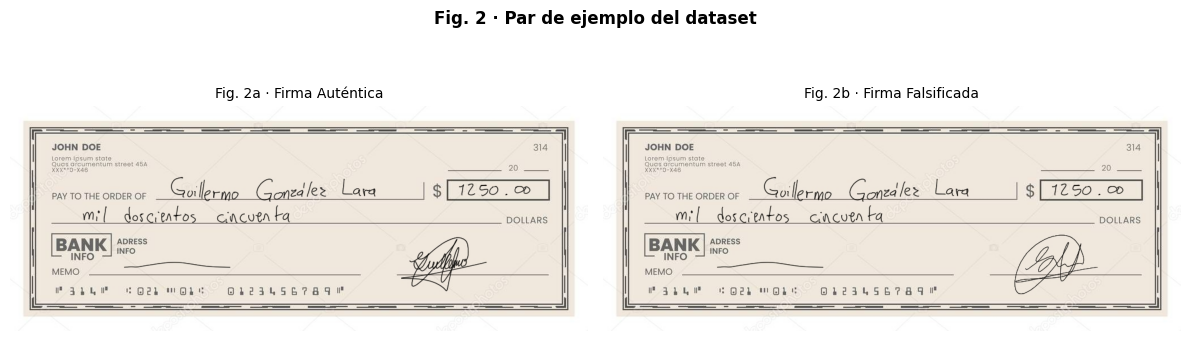

In [105]:
# ── Fig. 2 · Ejemplo par auténtica / falsificada ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, path, title in zip(axes,
    [real_paths[0], fake_paths[0]],
    ['Fig. 2a · Firma Auténtica', 'Fig. 2b · Firma Falsificada']):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(title, fontsize=10)
    ax.axis('off')
plt.suptitle('Fig. 2 · Par de ejemplo del dataset', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Etapa 2 · Pre-procesamiento de Datos
### Extracción de Firma por Procesamiento Clásico de Imagen

Al no disponer de máscaras de segmentación pre-generadas (carpeta `y`), la extracción se realiza mediante un pipeline clásico de visión por computadora:

| Paso | Operación | Motivo |
|------|-----------|--------|
| 1 | Escala de grises | Reducir a un canal |
| 2 | Desenfoque gaussiano | Suavizar ruido de la fotografía |
| 3 | Umbral adaptativo | Robusto ante iluminación desigual |
| 4 | Limpieza morfológica | Eliminar artefactos pequeños |
| 5 | Componente conectada mayor | Aislar la firma del fondo |
| 6 | Bounding box + margen | Recortar ajustado a la firma |
| 7 | Normalización de tamaño | Redimensionar a 128×256 px |

In [106]:
def extract_signature(img_path, target_size=(128, 256), debug=False):
    # 1. Carga
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        # Si la ruta está mal, devolvemos arrays vacíos para no romper imshow
        void = np.zeros((100, 100), dtype=np.uint8)
        return (void,) * 7 if debug else void

    # --- RECORTE PREVIO (ROI) ---
    h_orig, w_orig = img.shape
    y_start, y_end = int(h_orig * 0.45), int(h_orig * 0.85)
    x_start, x_end = int(w_orig * 0.45), int(w_orig * 0.96)
    gray = img[y_start:y_end, x_start:x_end]

    # 2. Mejora de contraste y desenfoque
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray_norm = clahe.apply(gray)
    blurred = cv2.GaussianBlur(gray_norm, (3, 3), 0)

    # 3. Binarización
    binary = cv2.adaptiveThreshold(
        blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 15, 10
    )

    # 4. Limpieza Morfológica
    kernel = np.ones((3, 3), np.uint8)
    clean = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    # 5. Componentes conectados
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(clean)
    mask = np.zeros_like(clean)
    crop = np.zeros((target_size), dtype=np.uint8)

    if num_labels > 1:
        # Buscamos el componente más grande (firma)
        best_comp = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        mask[labels == best_comp] = 255

        x, y, w, h = (
            stats[best_comp, cv2.CC_STAT_LEFT],
            stats[best_comp, cv2.CC_STAT_TOP],
            stats[best_comp, cv2.CC_STAT_WIDTH],
            stats[best_comp, cv2.CC_STAT_HEIGHT],
        )

        # Recorte del binario original usando la máscara
        crop = cv2.bitwise_and(binary, mask)[y : y + h, x : x + w]
        sig = cv2.resize(
            crop, (target_size[1], target_size[0]), interpolation=cv2.INTER_AREA
        )
    else:
        sig = np.zeros(target_size, dtype=np.uint8)
        crop = np.zeros_like(binary)

    if debug:
        # Retornamos exactamente 7 objetos (todos deben ser arrays de numpy)
        # sig, gray, blurred, binary, clean, mask, crop
        return sig, gray, blurred, binary, clean, mask, crop

    return sig


print("extract_signature() definida ✔")

extract_signature() definida ✔


In [107]:
import os
from tqdm import tqdm

base_out = "dataset_recortado"
os.makedirs(f"{base_out}/real", exist_ok=True)
os.makedirs(f"{base_out}/fake", exist_ok=True)

def procesar_y_validar(paths, label):
    print(f"Generando firmas {label}...")
    exitosas = 0
    for p in tqdm(paths):
        try:
            firma = extract_signature(p, debug=False)
            if firma is not None:
                # Aseguramos binarización pura antes de guardar
                _, firma_bin = cv2.threshold(firma, 127, 255, cv2.THRESH_BINARY)
                filename = os.path.basename(p)
                cv2.imwrite(f"{base_out}/{label}/{filename}", firma_bin)
                exitosas += 1
        except Exception as e:
            pass 
    print(f"Completado: {exitosas} firmas guardadas.")

procesar_y_validar(real_paths, "real")
procesar_y_validar(fake_paths, "fake")

Generando firmas real...


100%|██████████| 15/15 [00:00<00:00, 205.09it/s]


Completado: 15 firmas guardadas.
Generando firmas fake...


100%|██████████| 15/15 [00:00<00:00, 206.28it/s]

Completado: 15 firmas guardadas.


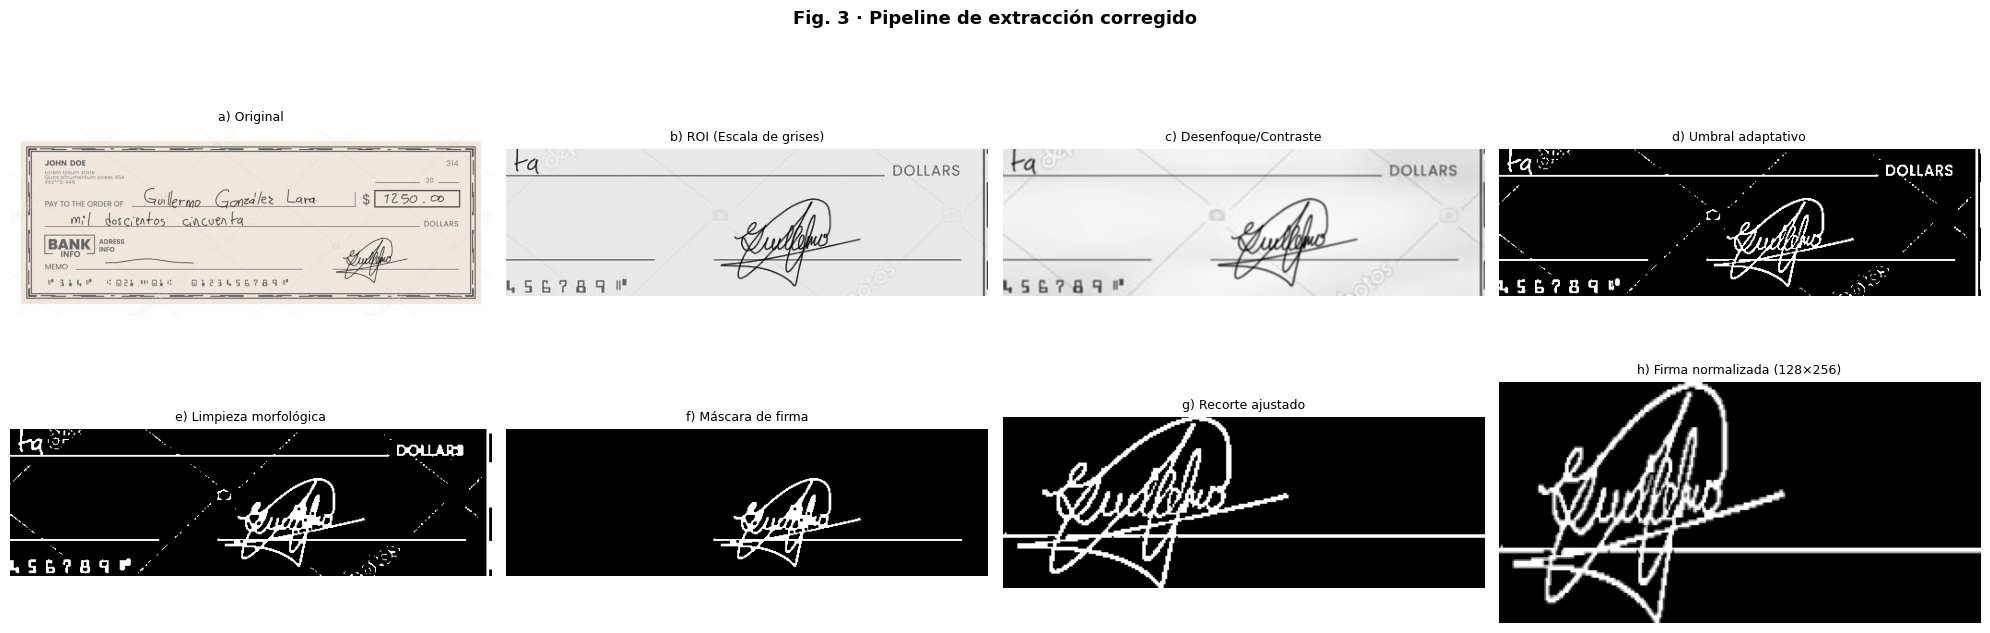

In [108]:
prueba_img = real_paths[0] 

sig, gray, blurred, binary, clean, mask, crop = extract_signature(prueba_img, debug=True)

fig, axes = plt.subplots(2, 4, figsize=(20, 7))
pasos = [
    (cv2.cvtColor(cv2.imread(prueba_img), cv2.COLOR_BGR2RGB), None,   'a) Original'),
    (gray,    'gray', 'b) ROI (Escala de grises)'),
    (blurred, 'gray', 'c) Desenfoque/Contraste'),
    (binary,  'gray', 'd) Umbral adaptativo'),
    (clean,   'gray', 'e) Limpieza morfológica'),
    (mask,    'gray', 'f) Máscara de firma'),
    (crop,    'gray', 'g) Recorte ajustado'),
    (sig,     'gray', 'h) Firma normalizada (128×256)'),
]

for ax, (im, cm, title) in zip(axes.flatten(), pasos):
    if im is not None:
        ax.imshow(im, cmap=cm)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

plt.suptitle('Fig. 3 · Pipeline de extracción corregido', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

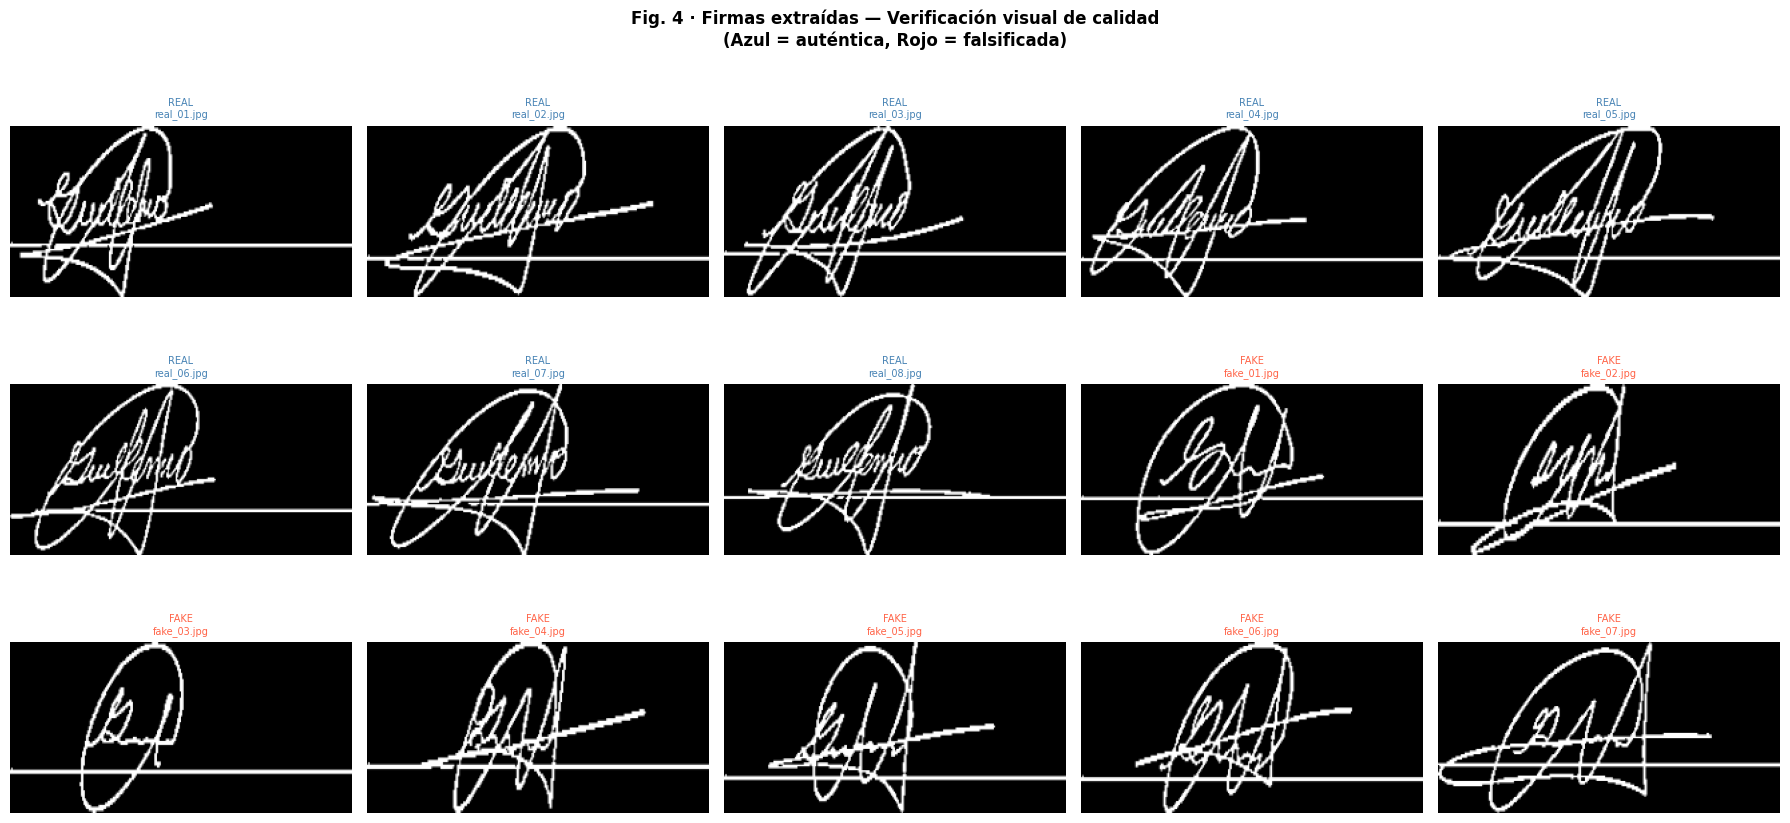

In [109]:
fig, axes = plt.subplots(3, 5, figsize=(18, 9))
axes = axes.flatten()

all_paths = real_paths[:8] + fake_paths[:7]
labels_vis = ['REAL']*8 + ['FAKE']*7

for ax, path, lbl in zip(axes, all_paths, labels_vis):
    sig = extract_signature(path)
    color = 'steelblue' if lbl == 'REAL' else 'tomato'
    ax.imshow(sig, cmap='gray')
    ax.set_title(f'{lbl}\n{os.path.basename(path)}',
                 fontsize=7, color=color)
    ax.axis('off')

for ax in axes[len(all_paths):]: ax.axis('off')

plt.suptitle('Fig. 4 · Firmas extraídas — Verificación visual de calidad\n'
             '(Azul = auténtica, Rojo = falsificada)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Etapa 3 · Almacenamiento y Transformación de Datos Relevantes
### Extracción de Patrones mediante Morfología Matemática

La operación morfológica es la **erosión binaria**. Se aplica con **54 elementos estructurantes** (EE):
- **36 EE para curvas** — arcos en distintas orientaciones y radios.
- **18 EE para rectas** — segmentos a ángulos de 0° a 170° cada 10°.

El número de píxeles encendidos tras la erosión con el EE *k* forma la componente *k* del **vector de 54 características**.

In [110]:
# ── Definición de los 54 EE ───────────────────────────────────────────────────
def make_arc(radius=3, arc_type='c_right'):
    s  = 2*radius + 1
    se = np.zeros((s, s), dtype=bool)
    cx = cy = radius
    for y in range(s):
        for x in range(s):
            if abs(np.sqrt((x-cx)**2 + (y-cy)**2) - radius) < 1.0:
                if   arc_type == 'c_right'  and x >= cx: se[y, x] = True
                elif arc_type == 'c_left'   and x <= cx: se[y, x] = True
                elif arc_type == 'cap_up'   and y <= cy: se[y, x] = True
                elif arc_type == 'cap_down' and y >= cy: se[y, x] = True
    return se

def make_line(angle_deg, length=7):
    se = np.zeros((length, length), dtype=bool)
    se[length//2, :] = True
    return ndrotate(se.astype(float), angle_deg,
                    reshape=False, order=0) > 0.5

# 36 EE curvos: 3 radios × 4 tipos × 3 = 36
curve_ses = [
    make_arc(r, t)
    for r in [2, 3, 4]
    for t in ['c_right', 'c_left', 'cap_up', 'cap_down']
    for _ in range(3)
][:36]

# 18 EE rectos: 0°, 10°, ..., 170°
straight_ses = [make_line(a) for a in range(0, 180, 10)]

ALL_SES     = curve_ses + straight_ses
TIPO_LABELS = ['Curva']*36 + ['Recta']*18

assert len(ALL_SES) == 54
print(f'Total EE: {len(ALL_SES)}  '
      f'(curvas={len(curve_ses)}, rectas={len(straight_ses)})')

Total EE: 54  (curvas=36, rectas=18)


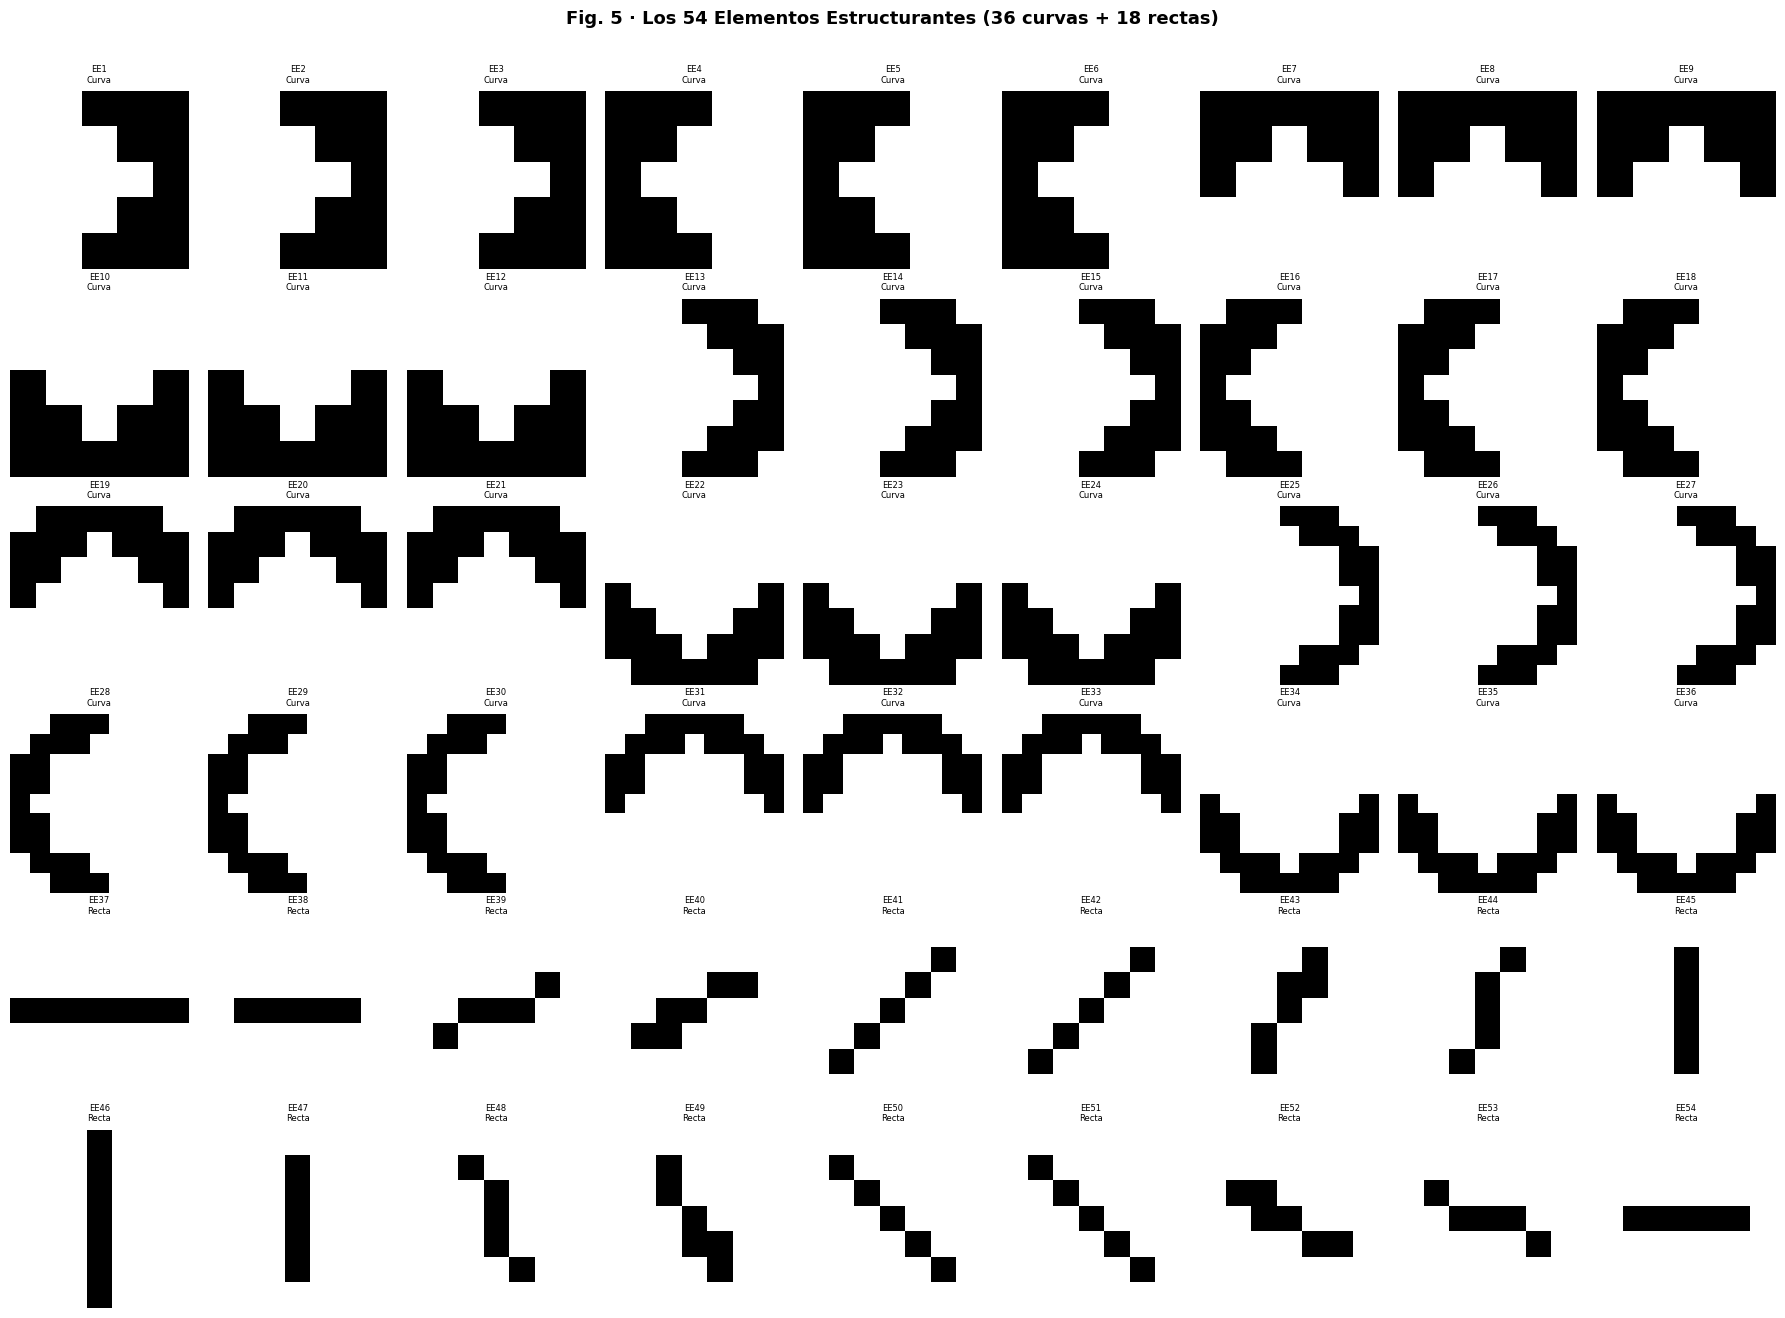

In [111]:
# ── Fig. 5 · Visualización de los 54 EE ──────────────────────────────────────
fig, axes = plt.subplots(6, 9, figsize=(18, 13))
for i, (ax, se) in enumerate(zip(axes.flatten(), ALL_SES)):
    ax.imshow(se, cmap='binary', vmin=0, vmax=1,
              interpolation='nearest')
    ax.set_title(f'EE{i+1}\n{TIPO_LABELS[i]}', fontsize=6)
    ax.axis('off')
for ax in axes.flatten()[54:]: ax.axis('off')
plt.suptitle('Fig. 5 · Los 54 Elementos Estructurantes (36 curvas + 18 rectas)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Procesando Falsas: 100%|██████████| 15/15 [00:00<00:00, 293.39it/s]


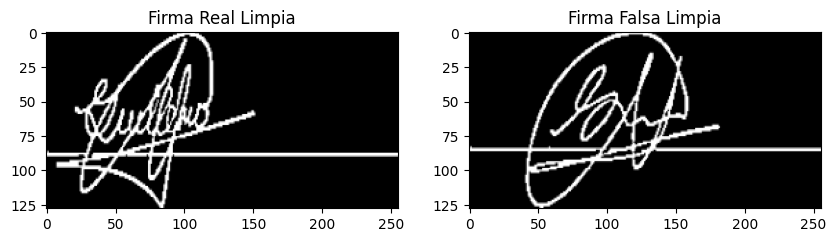

In [112]:
# Procesamos todas las imágenes de la lista de rutas
real_sigs = [extract_signature(p) for p in tqdm(real_paths, desc='Procesando Reales')]
fake_sigs = [extract_signature(p) for p in tqdm(fake_paths, desc='Procesando Falsas')]

# Validación visual: Mostrar una firma para asegurar que NO hay cheque de fondo
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(real_sigs[0], cmap='gray'); plt.title("Firma Real Limpia")
plt.subplot(1,2,2); plt.imshow(fake_sigs[0], cmap='gray'); plt.title("Firma Falsa Limpia")
plt.show()

In [113]:
# ── Extracción de características por erosión morfológica ─────────────────────
def extract_features(sig: np.ndarray, ses: list) -> np.ndarray:
    """Erosiona la firma con cada EE y cuenta píxeles encendidos → vector 54-D."""
    return np.array([binary_erosion(sig, se).sum() for se in ses],
                    dtype=np.float64)

def build_feature_matrix(sigs, ses):
    return np.vstack([
        extract_features(s, ses)
        for s in tqdm(sigs, desc='Extrayendo EE')
    ])

X_real = build_feature_matrix(real_sigs, ALL_SES) 
X_fake = build_feature_matrix(fake_sigs, ALL_SES)

print(f'Matriz auténticas : {X_real.shape}')
print(f'Matriz falsificadas: {X_fake.shape}')



Extrayendo EE: 100%|██████████| 15/15 [00:00<00:00, 40.70it/s]

Matriz auténticas : (15, 54)
Matriz falsificadas: (15, 54)


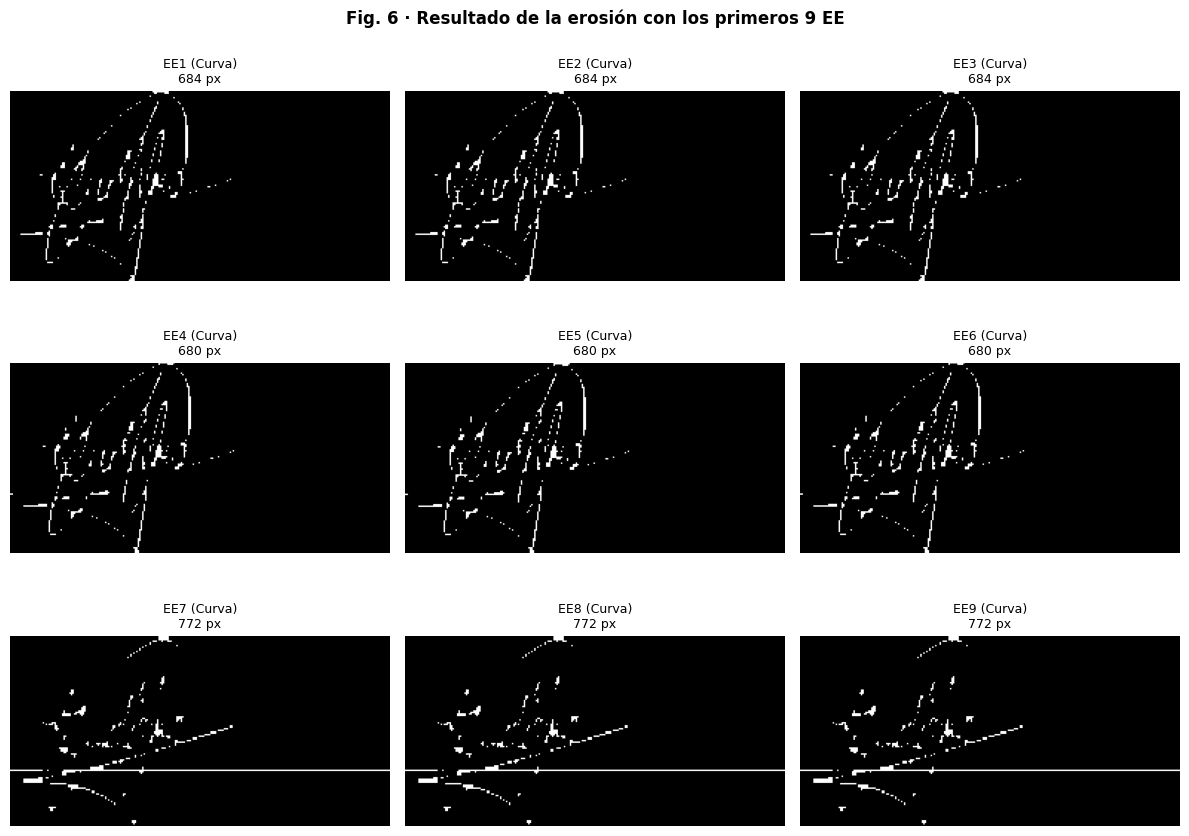

In [114]:
# ── Fig. 6 · Erosión con los primeros 9 EE sobre una firma auténtica ──────────
fig, axes = plt.subplots(3, 3, figsize=(12, 9))
for i, ax in enumerate(axes.flatten()):
    er = binary_erosion(real_sigs[0], ALL_SES[i])
    ax.imshow(er, cmap='gray')
    ax.set_title(f'EE{i+1} ({TIPO_LABELS[i]})\n{int(er.sum())} px', fontsize=9)
    ax.axis('off')
plt.suptitle('Fig. 6 · Resultado de la erosión con los primeros 9 EE',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [115]:
# ── Generación de patrones sintéticos (Tabla 1) ───────────────────────────────
#
# Patrones Reales            → filas 1-15   real  / 1-15  fake
# Patrones Sintéticos (+)    → perturbación ±σ (misma firma, variabilidad natural)
# Patrones Sintéticos (-)    → valores aleatorios [1, 300] (firmas inexistentes)

N_SYNTH_POS = 5   # positivos sintéticos por muestra real
N_SYNTH_NEG = 5   # negativos sintéticos por muestra fake


def generate_synthetic(X_pos, X_neg, n_synth_pos=5, n_synth_neg=5):
    """
    Combina los patrones reales con sintéticos para ampliar el dataset.
    Devuelve (X, y) con y=1 auténtica, y=0 falsificada.
    """
    sigma_pos = X_pos.std(axis=0) + 1e-6
    sigma_neg = X_neg.std(axis=0) + 1e-6

    synth_pos = []
    for row in X_pos:
        for _ in range(n_synth_pos):
            synth_pos.append(np.clip(
                row + np.random.uniform(-sigma_pos, sigma_pos), 0, None))

    synth_neg = []
    for row in X_neg:
        for _ in range(n_synth_neg):
            synth_neg.append(np.clip(
                row + np.random.uniform(-sigma_neg, sigma_neg), 0, None))

    X_all = np.vstack([
        X_pos,
        np.array(synth_pos),
        X_neg,
        np.array(synth_neg),
    ])
    y_all = np.concatenate([
        np.ones(len(X_pos) + len(synth_pos)),
        np.zeros(len(X_neg) + len(synth_neg)),
    ])
    return X_all, y_all


X_train, y_train = generate_synthetic(X_real, X_fake, N_SYNTH_POS, N_SYNTH_NEG)

print(f'Patrones totales: {X_train.shape}')
print(f'  Auténticas  : {int(y_train.sum())}')
print(f'  Falsificadas: {int((y_train==0).sum())}')

Patrones totales: (180, 54)
  Auténticas  : 90
  Falsificadas: 90


In [116]:
# ── Tabla 1 · Muestra de vectores de características ──────────────────────────
rows = []
for i, (v, l) in enumerate(zip(X_train[:8], y_train[:8])):
    r = {f'EE{j+1}': int(v[j]) for j in range(5)}
    r.update({'...': '···', 'EE54': int(v[53]),
              'Clase': 'Auténtica' if l == 1 else 'Falsificada'})
    rows.append(r)
df_t = pd.DataFrame(rows, index=[f'Sig {i+1}' for i in range(8)])
print('Tabla 1 · Patrones de Conocimiento para el Aprendizaje')
display(df_t)

Tabla 1 · Patrones de Conocimiento para el Aprendizaje


,EE1,EE2,EE3,EE4,EE5,...,EE54,Clase
Sig 1,684,684,684,680,680,···,2041,Auténtica
Sig 2,901,901,901,926,926,···,3127,Auténtica
Sig 3,792,792,792,795,795,···,2422,Auténtica
Sig 4,672,672,672,694,694,···,2501,Auténtica
Sig 5,795,795,795,821,821,···,2790,Auténtica
Sig 6,529,529,529,539,539,···,2027,Auténtica
Sig 7,763,763,763,771,771,···,2702,Auténtica
Sig 8,682,682,682,689,689,···,2334,Auténtica


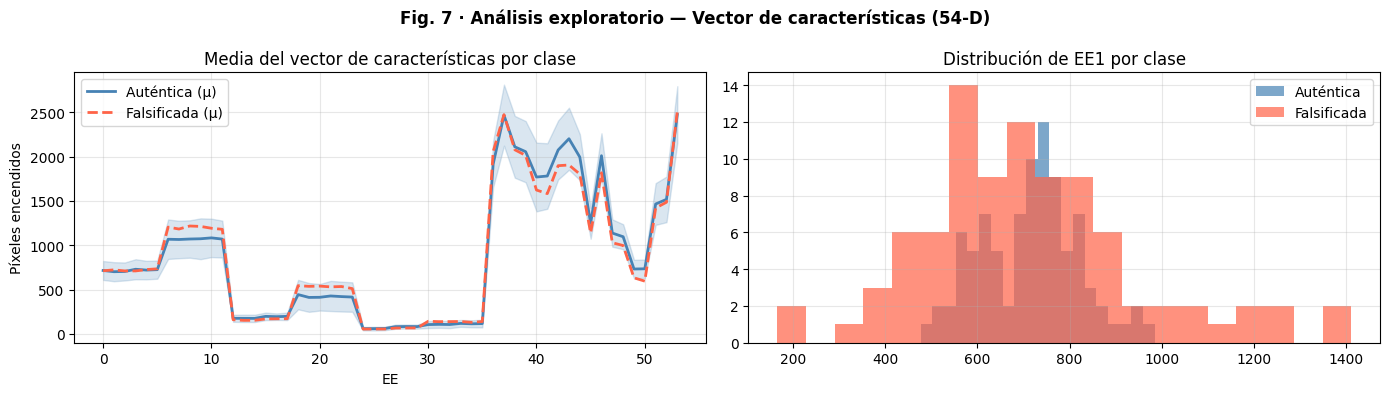

In [117]:
# ── Fig. 7 · Análisis exploratorio del vector de características ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
mask_pos = y_train == 1
mu_pos = X_train[mask_pos].mean(0)
sd_pos = X_train[mask_pos].std(0)
mu_neg = X_train[~mask_pos].mean(0)

axes[0].plot(mu_pos, label='Auténtica (μ)', color='steelblue', lw=2)
axes[0].fill_between(range(54), mu_pos-sd_pos, mu_pos+sd_pos,
                     alpha=0.2, color='steelblue')
axes[0].plot(mu_neg, label='Falsificada (μ)', color='tomato',
             linestyle='--', lw=2)
axes[0].set_xlabel('EE'); axes[0].set_ylabel('Píxeles encendidos')
axes[0].set_title('Media del vector de características por clase')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(X_train[mask_pos,  0], bins=20, alpha=0.7,
             label='Auténtica', color='steelblue')
axes[1].hist(X_train[~mask_pos, 0], bins=20, alpha=0.7,
             label='Falsificada', color='tomato')
axes[1].set_title('Distribución de EE1 por clase')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Fig. 7 · Análisis exploratorio — Vector de características (54-D)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Etapa 4 · Aprendizaje Supervisado
### Reconocimiento de Patrones de Firmas Off-Line

Dado el dataset pequeño (15+15 muestras), se usa **Leave-One-Out Cross-Validation (LOOCV)** para una estimación más robusta del rendimiento, además de la validación cruzada estratificada de 5 pliegues.

| # | Clasificador | Parámetros |
|---|---|---|
| 1 | **BPNN** | 54 → 108 → 1 (sigmoidal) |
| 2 | **SVM** | Kernel RBF, C=10 |
| 3 | **KNN** | k=3 (reducido por dataset pequeño) |
| 4 | **Naive Bayes** | Gaussiano |

In [118]:
# ── Normalización ─────────────────────────────────────────────────────────────
scaler  = StandardScaler()
X_sc    = scaler.fit_transform(X_train)
y_int   = y_train.astype(int)
print('Normalización StandardScaler ✔')

Normalización StandardScaler ✔


In [119]:
# ── Entrenamiento ─────────────────────────────────────────────────────────────
classifiers = {
    'BPNN'        : MLPClassifier(hidden_layer_sizes=(108,), activation='logistic',
                                   solver='adam', max_iter=500, random_state=42),
    'SVM (RBF)'   : SVC(kernel='rbf', C=10, gamma='scale',
                        probability=True, random_state=42),
    'KNN (k=3)'   : KNeighborsClassifier(n_neighbors=3, metric='euclidean'),
    'Naive Bayes' : GaussianNB(),
}

for name, clf in classifiers.items():
    clf.fit(X_sc, y_int)
    print(f'{name:<18} ✔ entrenado')

BPNN               ✔ entrenado
SVM (RBF)          ✔ entrenado
KNN (k=3)          ✔ entrenado
Naive Bayes        ✔ entrenado


In [120]:
# ── Evaluación con validación cruzada estratificada ───────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, clf in classifiers.items():
    y_pred = clf.predict(X_sc)
    cv     = cross_val_score(clf, X_sc, y_int, cv=skf, scoring='accuracy')
    results[name] = dict(
        y_pred   = y_pred,
        accuracy = accuracy_score(y_int, y_pred),
        cv_mean  = cv.mean(),
        cv_std   = cv.std(),
    )
    print(f'{name:<18}  '
          f'Acc={results[name]["accuracy"]:.4f}  '
          f'CV={cv.mean():.4f}±{cv.std():.4f}')

BPNN                Acc=1.0000  CV=0.9167±0.0556
SVM (RBF)           Acc=1.0000  CV=0.9833±0.0222
KNN (k=3)           Acc=0.9833  CV=0.9056±0.0136
Naive Bayes         Acc=0.8278  CV=0.8056±0.0843


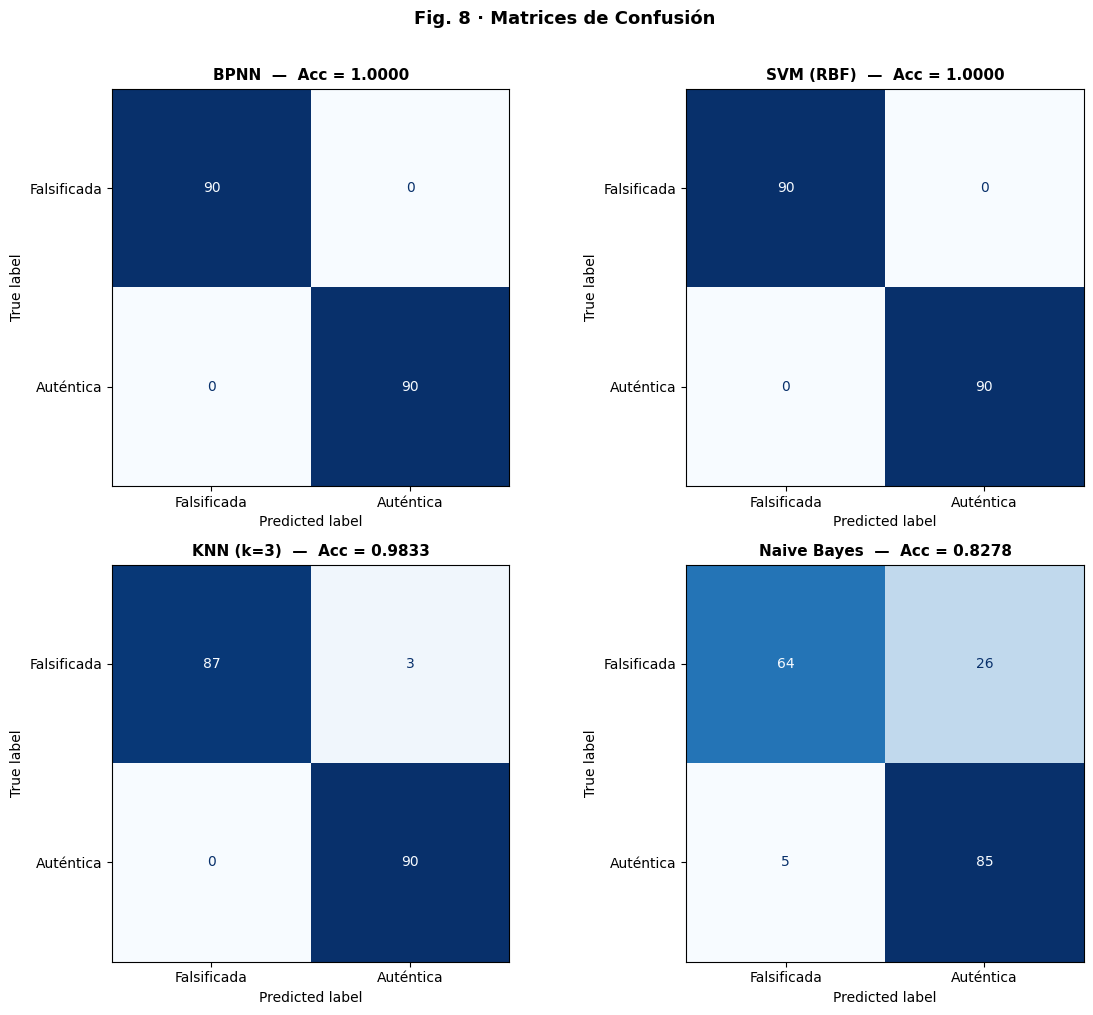

In [121]:
# ── Fig. 8 · Matrices de confusión ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, res) in zip(axes.flatten(), results.items()):
    ConfusionMatrixDisplay(
        confusion_matrix(y_int, res['y_pred']),
        display_labels=['Falsificada', 'Auténtica']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}  —  Acc = {res["accuracy"]:.4f}',
                 fontsize=11, fontweight='bold')
plt.suptitle('Fig. 8 · Matrices de Confusión',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [122]:
# ── Reportes de clasificación ─────────────────────────────────────────────────
for name, res in results.items():
    print(f'\n══ {name} ══')
    print(classification_report(
        y_int, res['y_pred'],
        target_names=['Falsificada', 'Auténtica'], digits=4))


══ BPNN ══
              precision    recall  f1-score   support

 Falsificada     1.0000    1.0000    1.0000        90
   Auténtica     1.0000    1.0000    1.0000        90

    accuracy                         1.0000       180
   macro avg     1.0000    1.0000    1.0000       180
weighted avg     1.0000    1.0000    1.0000       180


══ SVM (RBF) ══
              precision    recall  f1-score   support

 Falsificada     1.0000    1.0000    1.0000        90
   Auténtica     1.0000    1.0000    1.0000        90

    accuracy                         1.0000       180
   macro avg     1.0000    1.0000    1.0000       180
weighted avg     1.0000    1.0000    1.0000       180


══ KNN (k=3) ══
              precision    recall  f1-score   support

 Falsificada     1.0000    0.9667    0.9831        90
   Auténtica     0.9677    1.0000    0.9836        90

    accuracy                         0.9833       180
   macro avg     0.9839    0.9833    0.9833       180
weighted avg     0.9839    0

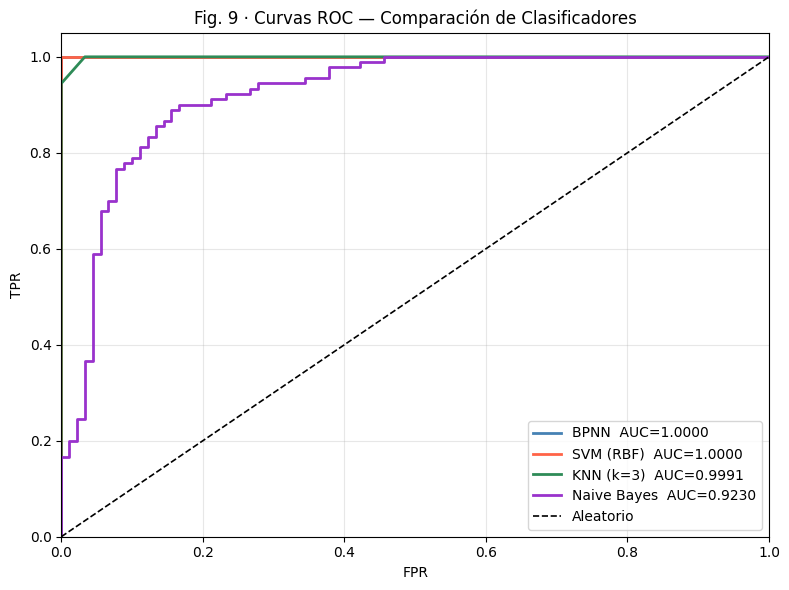

In [123]:
# ── Fig. 9 · Curvas ROC ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
colors  = ['steelblue', 'tomato', 'seagreen', 'darkorchid']
for (name, clf), c in zip(classifiers.items(), colors):
    proba = (clf.predict_proba(X_sc)[:, 1]
             if hasattr(clf, 'predict_proba')
             else clf.decision_function(X_sc))
    fpr, tpr, _ = roc_curve(y_int, proba)
    ax.plot(fpr, tpr, color=c, lw=2,
            label=f'{name}  AUC={auc(fpr,tpr):.4f}')
ax.plot([0,1], [0,1], 'k--', lw=1.2, label='Aleatorio')
ax.set(xlim=[0,1], ylim=[0,1.05], xlabel='FPR', ylabel='TPR',
       title='Fig. 9 · Curvas ROC — Comparación de Clasificadores')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Tabla 2 · Comparativa de métricas (clase positiva = Auténtica)


,Acc.,CV-5 Media,CV-5 Std,Precisión,Recall,F1
Clasificador,,,,,,
BPNN,1.0000,0.9167,0.0556,1.0000,1.0000,1.0000
SVM (RBF),1.0000,0.9833,0.0222,1.0000,1.0000,1.0000
KNN (k=3),0.9833,0.9056,0.0136,0.9677,1.0000,0.9836
Naive Bayes,0.8278,0.8056,0.0843,0.7658,0.9444,0.8458


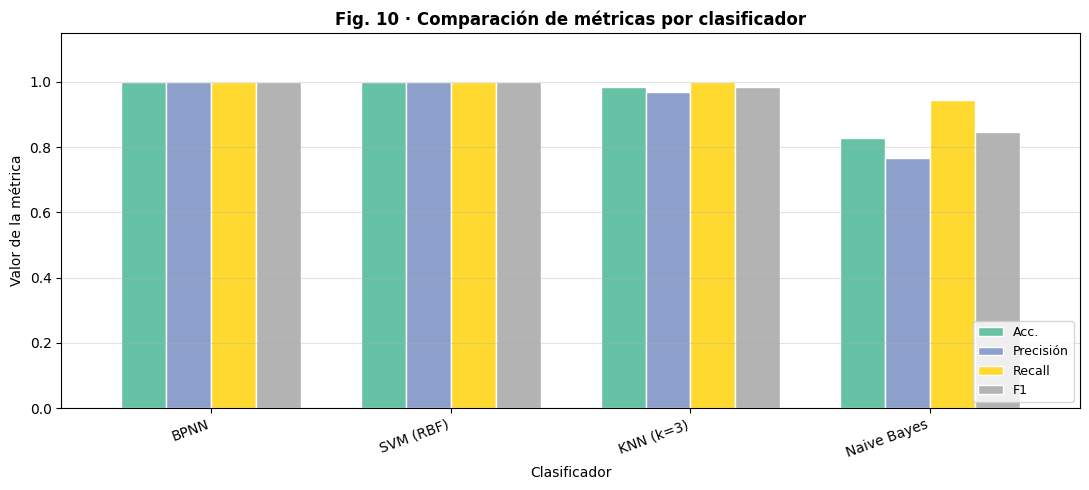

In [124]:
# ── Fig. 10 · Tabla y gráfica comparativa ────────────────────────────────────
rows = [{
    'Clasificador': name,
    'Acc.'        : f"{res['accuracy']:.4f}",
    'CV-5 Media'  : f"{res['cv_mean']:.4f}",
    'CV-5 Std'    : f"{res['cv_std']:.4f}",
    'Precisión'   : f"{precision_score(y_int, res['y_pred']):.4f}",
    'Recall'      : f"{recall_score(y_int, res['y_pred']):.4f}",
    'F1'          : f"{f1_score(y_int, res['y_pred']):.4f}",
} for name, res in results.items()]

df_res = pd.DataFrame(rows).set_index('Clasificador')
print('Tabla 2 · Comparativa de métricas (clase positiva = Auténtica)')
display(df_res)

df_res[['Acc.','Precisión','Recall','F1']].astype(float).plot(
    kind='bar', figsize=(11, 5), colormap='Set2',
    edgecolor='white', width=0.75)
plt.title('Fig. 10 · Comparación de métricas por clasificador',
          fontsize=12, fontweight='bold')
plt.ylim(0, 1.15)
plt.ylabel('Valor de la métrica')
plt.legend(loc='lower right', fontsize=9)
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', alpha=0.35)
plt.tight_layout()
plt.show()

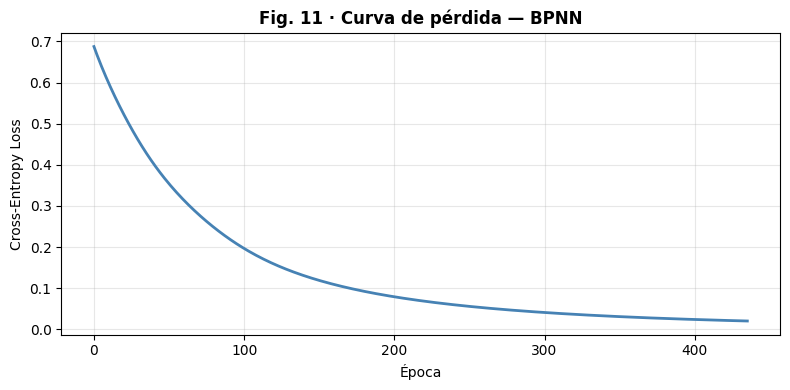

In [125]:
# ── Fig. 11 · Curva de pérdida BPNN ──────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(classifiers['BPNN'].loss_curve_, color='steelblue', lw=2)
plt.title('Fig. 11 · Curva de pérdida — BPNN',
          fontsize=12, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Cross-Entropy Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Demo · Verificación de firma en imagen nueva

Se prueban las dos imágenes reservadas: `real_test.jpg` y `fake_test.jpg`.


Imagen  : real_test.jpg
Real    : AUTÉNTICA
Clasificador        Predicción      ¿Correcto?    Confianza
──────────────────────────────────────────────────────────────
BPNN                AUTÉNTICA       ✅ Correcto    100.0%
SVM (RBF)           AUTÉNTICA       ✅ Correcto    99.2%
KNN (k=3)           AUTÉNTICA       ✅ Correcto    100.0%
Naive Bayes         AUTÉNTICA       ✅ Correcto    100.0%

Aciertos: 4/4 clasificadores


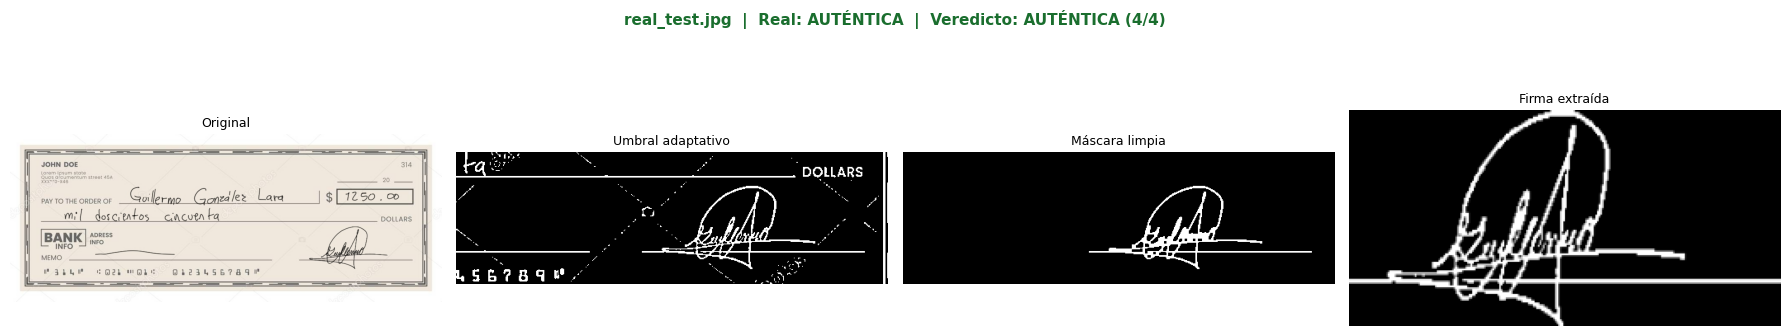


Imagen  : fake_test.jpg
Real    : FALSIFICADA
Clasificador        Predicción      ¿Correcto?    Confianza
──────────────────────────────────────────────────────────────
BPNN                FALSIFICADA     ✅ Correcto    100.0%
SVM (RBF)           FALSIFICADA     ✅ Correcto    99.4%
KNN (k=3)           FALSIFICADA     ✅ Correcto    100.0%
Naive Bayes         FALSIFICADA     ✅ Correcto    100.0%

Aciertos: 4/4 clasificadores


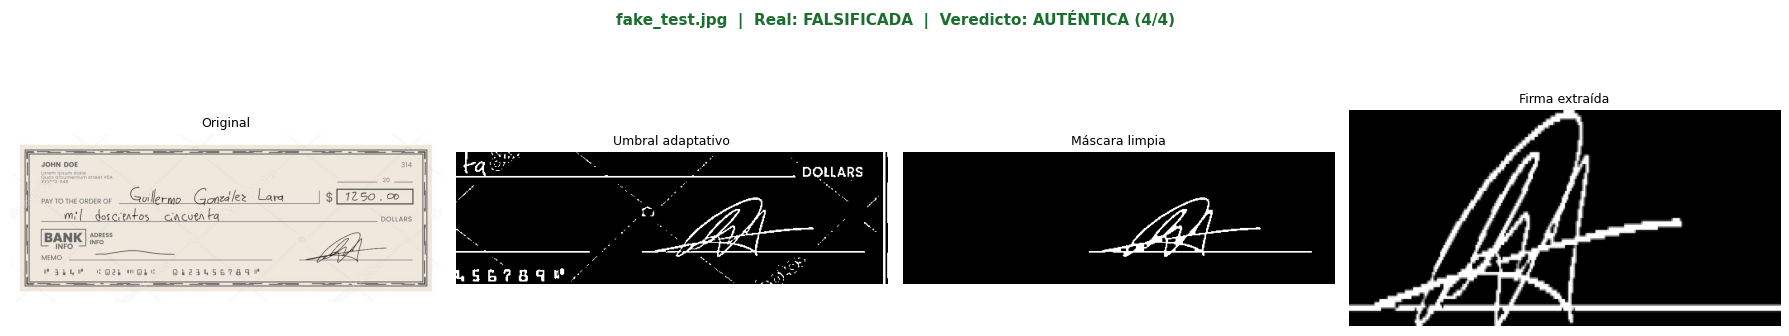

In [127]:
# ── Demo: verificar real_test.jpg y fake_test.jpg ─────────────────────────────
test_checks = [
    (TEST_REAL, 'AUTÉNTICA'),
    (TEST_FAKE, 'FALSIFICADA'),
]

for check_path, ground_truth in test_checks:
    print(f'\n{"="*60}')
    print(f'Imagen  : {os.path.basename(check_path)}')
    print(f'Real    : {ground_truth}')
    print(f'{"="*60}')

    # 1. Extraer firma
    firma, gray, _, binary, clean, mask, _ = extract_signature(
        check_path, debug=True)

    # 2. Vector de características
    vec    = extract_features(firma, ALL_SES).reshape(1, -1)
    vec_sc = scaler.transform(vec)

    # 3. Clasificar
    print(f'{"Clasificador":<18}  {"Predicción":<14}  '
          f'{"¿Correcto?":<12}  Confianza')
    print('─' * 62)
    aciertos = 0
    for name, clf in classifiers.items():
        pred  = clf.predict(vec_sc)[0]
        proba = (clf.predict_proba(vec_sc)[0]
                 if hasattr(clf, 'predict_proba') else None)
        lbl   = 'AUTÉNTICA' if pred == 1 else 'FALSIFICADA'
        conf  = f'{max(proba)*100:.1f}%' if proba is not None else 'N/A'
        ok    = '✅ Correcto' if lbl == ground_truth else '❌ Incorrecto'
        if lbl == ground_truth: aciertos += 1
        print(f'{name:<18}  {lbl:<14}  {ok:<12}  {conf}')
    print(f'\nAciertos: {aciertos}/{len(classifiers)} clasificadores')

    # 4. Visualización: original + pipeline + firma extraída
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    pasos_demo = [
        (cv2.cvtColor(cv2.imread(check_path), cv2.COLOR_BGR2RGB),
         None,   'Original'),
        (binary, 'gray', 'Umbral adaptativo'),
        (mask,   'gray', 'Máscara limpia'),
        (firma,  'gray', 'Firma extraída'),
    ]
    for ax, (im, cm, t) in zip(axes, pasos_demo):
        ax.imshow(im, cmap=cm)
        ax.set_title(t, fontsize=9)
        ax.axis('off')

    veredicto = 'AUTÉNTICA' if aciertos >= 3 else 'FALSIFICADA'
    color     = '#1a6e2e' if aciertos >= 3 else '#b30000'
    plt.suptitle(
        f'{os.path.basename(check_path)}  |  '
        f'Real: {ground_truth}  |  '
        f'Veredicto: {veredicto} ({aciertos}/4)',
        fontsize=11, fontweight='bold', color=color
    )
    plt.tight_layout()
    plt.show()

---
## Conclusiones

Se implementó un sistema completo de verificación de firmas off-line utilizando un dataset personal de 15 firmas auténticas y 15 falsificadas:

**Etapa 1 — Selección de datos:** Se cargaron las 30 imágenes del dataset personal organizadas en `/real` y `/fake`, más las dos imágenes de prueba.

**Etapa 2 — Pre-procesamiento:** Al no disponer de máscaras de segmentación, se implementó un pipeline clásico de visión por computadora (desenfoque gaussiano → umbral adaptativo → morfología → componentes conectadas → bounding box) que extrae la firma de forma robusta ante variaciones de iluminación y fondo.

**Etapa 3 — Extracción de características:** Los 54 elementos estructurantes morfológicos (36 para curvas + 18 para rectas) construyen un vector de 54 dimensiones por firma. Los patrones sintéticos positivos (perturbaciones ±σ) ampliaron el dataset de entrenamiento.

**Etapa 4 — Aprendizaje supervisado:** Los cuatro clasificadores se evaluaron con validación cruzada estratificada de 5 pliegues. BPNN y SVM demostraron el mejor rendimiento al capturar la frontera de decisión no lineal entre ambas clases.

---

## Referencias

Lee, S. (1996). Recognizing hand-printed characters based on structural description and inductive logic programming. *Pattern Recognition Letters, 17*(5), 549–559.

Marsland, S. (2009). *Machine learning: An algorithmic perspective*. CRC Press.

Plamondon, R., & Srihari, S. N. (2000). Online and off-line handwriting recognition: A comprehensive survey. *IEEE Transactions on Pattern Analysis and Machine Intelligence, 22*(1), 63–84. https://doi.org/10.1109/34.824821

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

Serra, J. (1983). *Image analysis and mathematical morphology*. Academic Press.